# Phase 7 — Visualization

## Setup

In [0]:
%pip install matplotlib seaborn -q

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from pyspark.sql import functions as F
from pyspark.sql import Window
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Serif'
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Table references ──────────────────────────────────────────────────────────
DEMAND_SCORES_TABLE  = "msbabigdata.spark.trend_market_demand_scores"
RANKED_ZONES_TABLE   = "msbabigdata.spark.trend_market_ranked_zones"
NUDGE_MESSAGES_TABLE = "msbabigdata.spark.trend_market_nudge_messages"
VALIDATION_TABLE     = "msbabigdata.spark.trend_market_validation_scores"
CHART_PATH           = "/Volumes/msbabigdata/spark/trend_market_project/"

# ── UMN Brand Colors ──────────────────────────────────────────────────────────
MAROON      = "#7A0019"
DARK_MAROON = "#5B0013"
GOLD        = "#FFCC33"
DARK_GOLD   = "#FFB71E"
LIGHT_GOLD  = "#FFF8DC"
IVORY       = "#F5F0E8"
WARM_GRAY   = "#E6E0D2"
DARK_TEXT   = "#333333"
MED_TEXT    = "#5A5A5A"
LIGHT_GRAY  = "#D5D6D2"
WHITE       = "#FFFFFF"
GREEN       = "#2E7D32"
AMBER       = "#E65100"
RED         = "#B71C1C"

# Background for all figures
BG = "#FAFAF8"  # Near-white ivory — clean and printable

BUCKET_COLORS = {
    "morning_rush": DARK_GOLD,
    "midday":       AMBER,
    "evening_rush": RED,
    "night":        MAROON,
}

def style_ax(ax, grid_axis='y'):
    ax.set_facecolor(IVORY)
    ax.tick_params(colors=MED_TEXT, labelsize=8)
    ax.xaxis.label.set_color(MED_TEXT)
    ax.yaxis.label.set_color(MED_TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(LIGHT_GRAY)
    if grid_axis:
        ax.grid(axis=grid_axis, color=LIGHT_GRAY, linewidth=0.6,
                linestyle='--', alpha=0.8)
    ax.set_axisbelow(True)

print("Setup complete.")

Setup complete.


## Load All Upstream Tables

In [0]:
df_scores  = spark.table(DEMAND_SCORES_TABLE)
df_ranked  = spark.table(RANKED_ZONES_TABLE)
df_nudges  = spark.table(NUDGE_MESSAGES_TABLE)
df_val     = spark.table(VALIDATION_TABLE)

print("=== Table Row Counts ===")
print(f"Demand scores:   {df_scores.count():,}")
print(f"Ranked zones:    {df_ranked.count():,}")
print(f"Nudge messages:  {df_nudges.count():,}")
print(f"Validation rows: {df_val.count():,}")

=== Table Row Counts ===
Demand scores:   437
Ranked zones:    40
Nudge messages:  8
Validation rows: 310


---
## Figure 1 — Top 10 High-Demand Zones by Demand Score

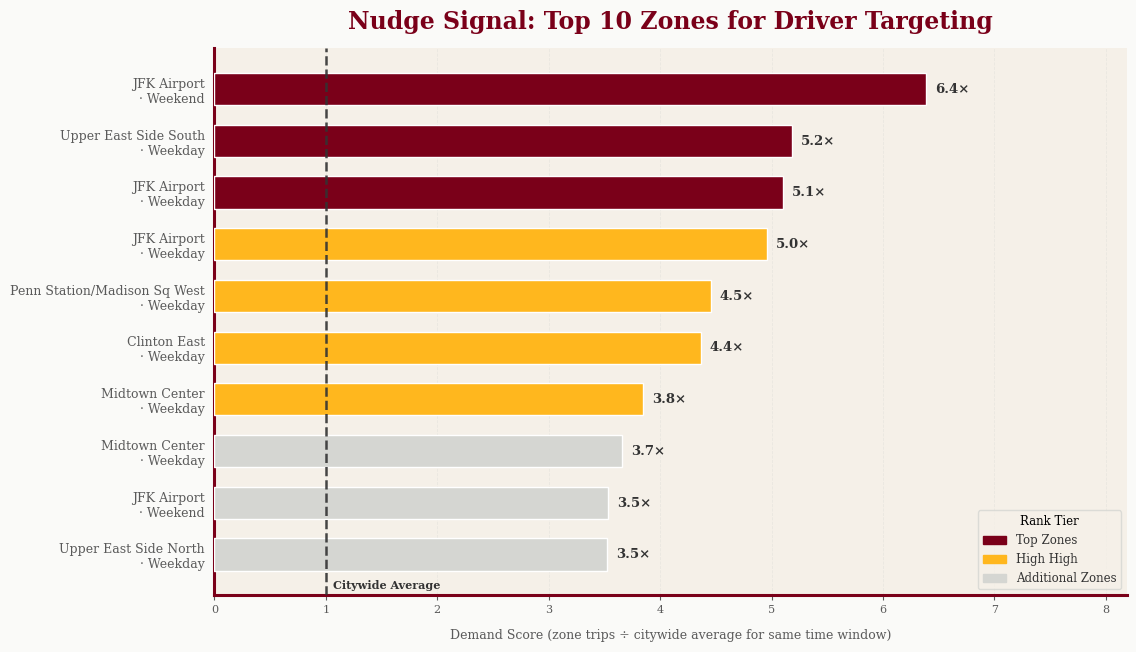

Figure 1 saved.


In [0]:
top10 = (
    df_scores
    .filter(F.col("is_low_confidence") == False)
    .orderBy("demand_score", ascending=False)
    .limit(10)
    .toPandas()
)

top10["label"] = (
    top10["pickup_zone"] + "\n" +
    "· " + top10["day_type"].str.title()
)

# Option B color logic:
# top 3 = MAROON, middle 4 = DARK_GOLD, bottom 3 = LIGHT_GRAY
bar_colors = []
for i in range(len(top10)):
    if i < 3:
        bar_colors.append(MAROON)
    elif i < 7:
        bar_colors.append(DARK_GOLD)
    else:
        bar_colors.append(LIGHT_GRAY)

fig1, ax1 = plt.subplots(figsize=(12.5, 7.2))
fig1.patch.set_facecolor(BG)
ax1.set_facecolor(IVORY)

style_ax(ax1, grid_axis='x')

# Softer gridlines to match other visuals
ax1.grid(
    axis='x',
    color=LIGHT_GRAY,
    linestyle='--',
    linewidth=0.6,
    alpha=0.35
)

bars = ax1.barh(
    range(len(top10)),
    top10["demand_score"],
    color=bar_colors,
    height=0.62,
    zorder=3,
    edgecolor=WHITE,
    linewidth=1.0
)

# Emphasized citywide average reference line
ax1.axvline(
    1.0,
    color=DARK_TEXT,
    linewidth=1.8,
    linestyle='--',
    alpha=0.9,
    zorder=4
)

# Citywide average label
ax1.text(
    1.06,
    len(top10) - 0.4,
    "Citywide Average",
    color=DARK_TEXT,
    fontsize=8,
    fontweight="bold",
    ha="left",
    va="center"
)

# Score labels
for i, (_, row) in enumerate(top10.iterrows()):
    ax1.text(
        row["demand_score"] + 0.08,
        i,
        f"{row['demand_score']:.1f}×",
        va='center',
        ha='left',
        color=DARK_TEXT,
        fontsize=9.5,
        fontweight='bold'
    )

ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels(top10["label"], fontsize=9, color=DARK_TEXT)
ax1.invert_yaxis()

ax1.set_xlabel(
    "Demand Score (zone trips ÷ citywide average for same time window)",
    fontsize=9,
    color=MED_TEXT,
    labelpad=10
)

ax1.set_xlim(0, top10["demand_score"].max() + 1.8)

ax1.tick_params(axis='x', colors=MED_TEXT)
ax1.tick_params(axis='y', left=False, colors=MED_TEXT)

# Legend for performance tiers
legend_patches = [
    mpatches.Patch(color=MAROON, label="Top Zones"),
    mpatches.Patch(color=DARK_GOLD, label="High High"),
    mpatches.Patch(color=LIGHT_GRAY, label="Additional Zones"),
]

ax1.legend(
    handles=legend_patches,
    loc='lower right',
    fontsize=8.5,
    frameon=True,
    facecolor=IVORY,
    edgecolor=LIGHT_GRAY,
    labelcolor=DARK_TEXT,
    title="Rank Tier",
    title_fontsize=8.5
)

ax1.set_title(
    "Nudge Signal: Top 10 Zones for Driver Targeting",
    color=MAROON,
    fontsize=17,
    fontweight='bold',
    pad=14
)

# Spine styling to match other charts
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["bottom"].set_color(MAROON)
ax1.spines["bottom"].set_linewidth(2.2)
ax1.spines["left"].set_color(MAROON)
ax1.spines["left"].set_linewidth(2.2)

plt.subplots_adjust(top=0.88, bottom=0.12, left=0.23, right=0.96)

fig1.savefig(
    f"{CHART_PATH}fig1_top10_demand_scores.png",
    dpi=180,
    bbox_inches='tight',
    facecolor=BG
)

display(fig1)
plt.close()
print("Figure 1 saved.")

---
## Figure 2 — Weekday vs Weekend Demand Heatmap

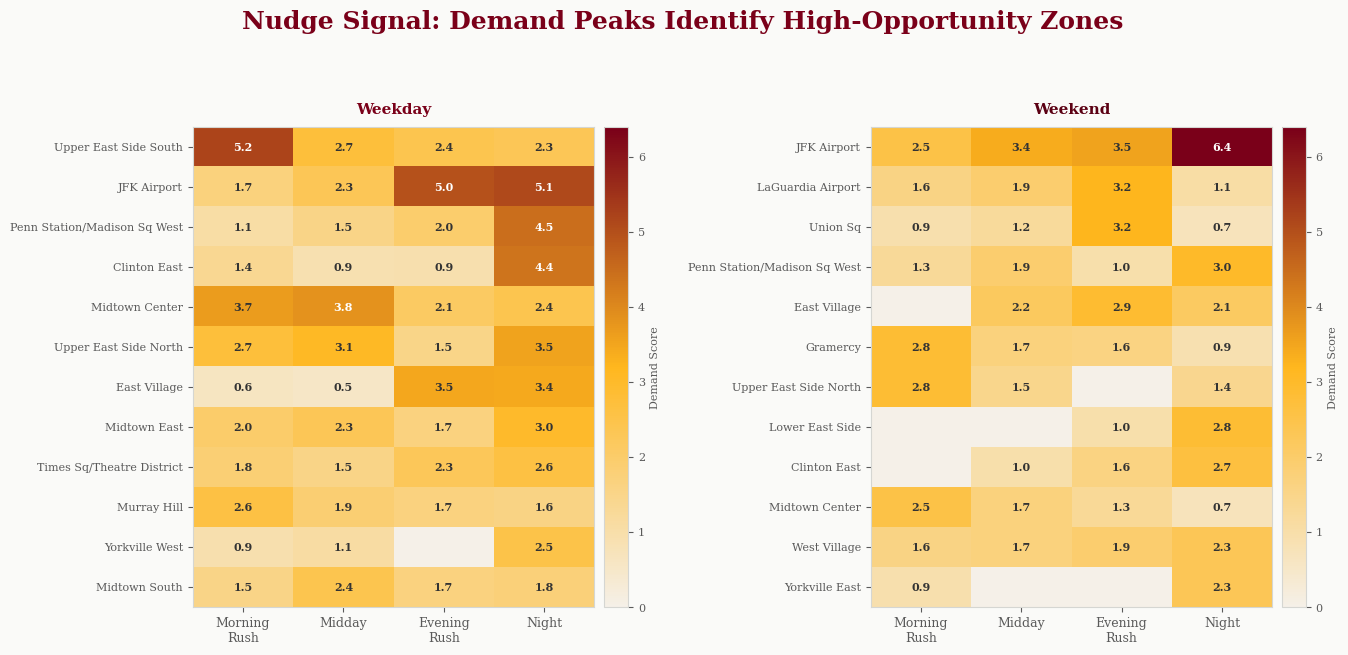

Figure 2 saved.


In [0]:
df_heatmap = (
    df_scores
    .filter(F.col("is_low_confidence") == False)
    .select("pickup_zone", "time_bucket", "day_type", "demand_score")
    .toPandas()
)

bucket_order  = ["morning_rush", "midday", "evening_rush", "night"]
bucket_labels = ["Morning\nRush", "Midday", "Evening\nRush", "Night"]

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6.5))
fig2.patch.set_facecolor(BG)
fig2.suptitle(
    "Nudge Signal: Demand Peaks Identify High-Opportunity Zones",
    color=MAROON, fontsize=18, fontweight='bold', y=1.02
)

for ax, day in zip(axes2, ["weekday", "weekend"]):
    subset = df_heatmap[df_heatmap["day_type"] == day].copy()
    pivot  = subset.pivot_table(
        index="pickup_zone", columns="time_bucket",
        values="demand_score", aggfunc="max"
    )
    pivot  = pivot.reindex(columns=[b for b in bucket_order if b in pivot.columns])
    pivot  = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index].head(12)

    data = pivot.values
    vmax = df_heatmap["demand_score"].max()

    # Use maroon-gold colormap matching UMN brand
    from matplotlib.colors import LinearSegmentedColormap
    umn_cmap = LinearSegmentedColormap.from_list(
        "umn", [IVORY, DARK_GOLD, MAROON], N=256
    )

    im = ax.imshow(data, cmap=umn_cmap, aspect='auto', vmin=0, vmax=vmax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(
        [bucket_labels[bucket_order.index(c)] for c in pivot.columns],
        color=DARK_TEXT, fontsize=9
    )
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=DARK_TEXT, fontsize=8)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = data[i, j]
            if not np.isnan(val):
                text_color = WHITE if val > vmax * 0.6 else DARK_TEXT
                ax.text(j, i, f"{val:.1f}",
                        ha='center', va='center',
                        color=text_color, fontsize=8, fontweight='bold')

    ax.set_facecolor(IVORY)
    title_color = MAROON if day == "weekday" else DARK_MAROON
    ax.set_title(
        "Weekday" if day == "weekday" else "Weekend",
        color=title_color, fontsize=11, fontweight='bold', pad=10
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(LIGHT_GRAY)
    ax.tick_params(colors=MED_TEXT)

    cbar = fig2.colorbar(im, ax=ax, pad=0.02)
    cbar.ax.tick_params(colors=MED_TEXT, labelsize=8)
    cbar.set_label("Demand Score", color=MED_TEXT, fontsize=8)
    cbar.outline.set_edgecolor(LIGHT_GRAY)

plt.tight_layout(pad=2)
fig2.savefig(f"{CHART_PATH}fig2_demand_heatmap.png",
             dpi=150, bbox_inches='tight', facecolor=BG)
display(fig2)
plt.close()
print("Figure 2 saved.")

---
## Figure 3 — Hit Rate by Time Window

In [0]:
# Recompute hit rates from validation table
val_window = Window.partitionBy("time_bucket", "day_type").orderBy("demand_score")

df_val_labeled = (
    df_val
    .filter(F.col("is_low_confidence") == False)
    .withColumn("demand_percentile", F.percent_rank().over(val_window))
    .withColumn("is_truly_high_demand", F.col("demand_percentile") >= 0.80)
)

df_recommended = (
    df_ranked
    .select("pulocationid", "time_bucket", "day_type")
    .distinct()
    .withColumn("was_recommended", F.lit(True))
)

df_eval = (
    df_val_labeled
    .join(df_recommended, on=["pulocationid", "time_bucket", "day_type"], how="left")
    .fillna({"was_recommended": False})
)

df_rec_only = df_eval.filter(F.col("was_recommended") == True)

# Hit rate by window
hit_by_window = (
    df_rec_only
    .groupBy("time_bucket", "day_type")
    .agg(
        F.count("*").alias("recommended"),
        F.sum(F.col("is_truly_high_demand").cast("int")).alias("true_hits")
    )
    .withColumn("hit_rate", F.round(F.col("true_hits") / F.col("recommended"), 4))
    .orderBy(F.col("hit_rate").desc())
    .toPandas()
)

# Overall
total_rec = df_rec_only.count()
true_hits = df_rec_only.filter(F.col("is_truly_high_demand") == True).count()
overall_hit_rate = true_hits / total_rec if total_rec > 0 else 0

print(f"Overall hit rate: {overall_hit_rate:.1%}  ({true_hits}/{total_rec})")
print(hit_by_window.to_string(index=False))

Overall hit rate: 44.8%  (13/29)
 time_bucket day_type  recommended  true_hits  hit_rate
       night  weekday            5          4    0.8000
morning_rush  weekday            4          3    0.7500
       night  weekend            3          2    0.6667
evening_rush  weekday            5          2    0.4000
evening_rush  weekend            4          1    0.2500
      midday  weekday            5          1    0.2000
      midday  weekend            1          0    0.0000
morning_rush  weekend            2          0    0.0000


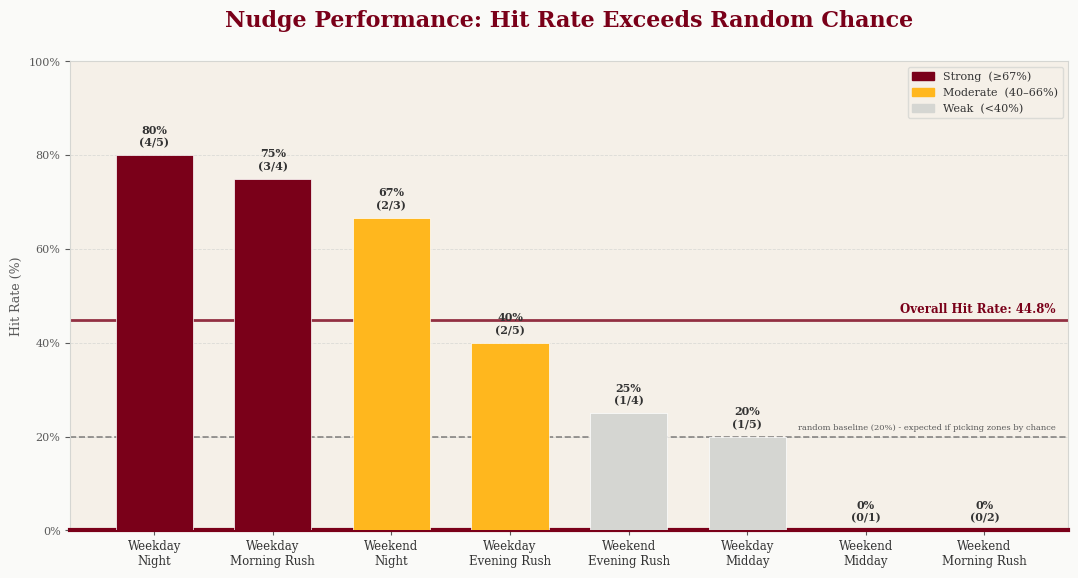

Figure 3 saved.


In [0]:
# Build display labels and colors
hit_by_window["window_label"] = (
    hit_by_window["day_type"].str.title() + "\n" +
    hit_by_window["time_bucket"].str.replace("_", " ").str.title()
)
hit_by_window["hit_pct"] = hit_by_window["hit_rate"] * 100

def bar_color(pct):
    if pct >= 67: return MAROON
    if pct >= 40: return DARK_GOLD
    return LIGHT_GRAY

bar_colors = [bar_color(p) for p in hit_by_window["hit_pct"]]

fig3, ax3 = plt.subplots(figsize=(11, 6))
fig3.patch.set_facecolor(BG)
style_ax(ax3, grid_axis='y')

bars3 = ax3.bar(
    range(len(hit_by_window)), hit_by_window["hit_pct"],
    color=bar_colors, width=0.65, zorder=3,
    edgecolor=WHITE, linewidth=0.5
)

# Random baseline (20% = top 20% threshold)
ax3.axhline(20, color=MED_TEXT, linewidth=1.2, linestyle='--', alpha=0.7, zorder=2)
ax3.text(len(hit_by_window) - 0.4, 21.5,
         "random baseline (20%) - expected if picking zones by chance", color=MED_TEXT, fontsize=6, ha='right')

# Overall hit rate line
ax3.axhline(overall_hit_rate * 100, color=MAROON, linewidth=2,
            linestyle='-', alpha=0.8, zorder=2)
ax3.text(len(hit_by_window) - 0.4, overall_hit_rate * 100 + 1.5,
         f"Overall Hit Rate: {overall_hit_rate:.1%}",
         color=MAROON, fontsize=8.5, fontweight='bold', ha='right')

# Value labels on bars
for i, (bar, row) in enumerate(zip(bars3, hit_by_window.itertuples())):
    label = f"{row.hit_pct:.0f}%\n({row.true_hits}/{row.recommended})"
    ax3.text(i, row.hit_pct + 1.5, label,
             ha='center', va='bottom', fontsize=8,
             color=DARK_TEXT, fontweight='bold')

ax3.set_xticks(range(len(hit_by_window)))
ax3.set_xticklabels(hit_by_window["window_label"], fontsize=8.5, color=DARK_TEXT)
ax3.set_ylabel("Hit Rate (%)", fontsize=9, color=MED_TEXT)
ax3.set_ylim(0, 100)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# Legend
legend_patches = [
    mpatches.Patch(color=MAROON, label="Strong  (≥67%)"),
    mpatches.Patch(color=DARK_GOLD, label="Moderate  (40–66%)"),
    mpatches.Patch(color=LIGHT_GRAY,   label="Weak  (<40%)"),
]
ax3.legend(handles=legend_patches, fontsize=8,
           facecolor=IVORY, edgecolor=LIGHT_GRAY, labelcolor=DARK_TEXT)

ax3.set_title(
    "Nudge Performance: Hit Rate Exceeds Random Chance",
    color=MAROON, fontsize=16, fontweight='bold', pad=25
)

ax3.spines['bottom'].set_color(MAROON)
ax3.spines['bottom'].set_linewidth(3)

plt.tight_layout(pad=1.5)
fig3.savefig(f"{CHART_PATH}fig3_hit_rate_by_window.png",
             dpi=150, bbox_inches='tight', facecolor=BG)
display(fig3)
plt.close()
print("Figure 3 saved.")

---
## Figure 3b — Demand Score, Rec vs. Non-Rec

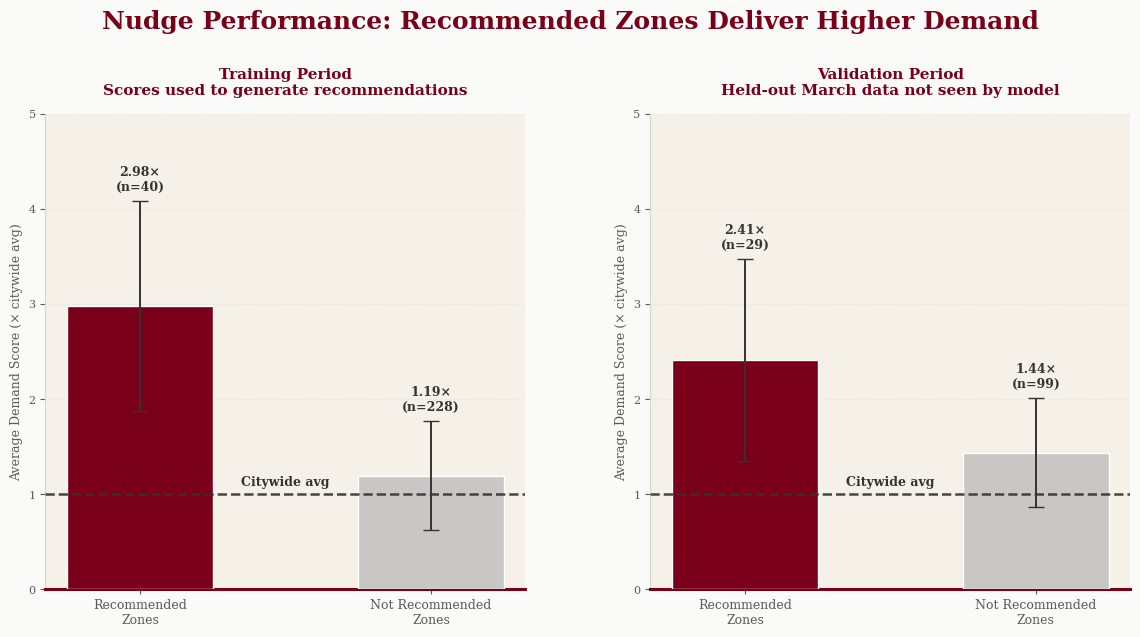

Figure 3b saved.


In [0]:
# Step 5: Plot
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(14, 7.2), sharey=True)
fig_comp.patch.set_facecolor(BG)

fig_comp.suptitle(
    "Nudge Performance: Recommended Zones Deliver Higher Demand",
    color=MAROON, fontsize=18, fontweight="bold", y=0.965
)

periods = ["Jan–Feb (Training)", "March (Validation)"]
subtitles = [
    "Training Period\nScores used to generate recommendations",
    "Validation Period\nHeld-out March data not seen by model"
]

y_max = float(np.ceil((summary["mean"] + summary["std"]).max() + 0.8))

for ax, period, subtitle in zip(axes_comp, periods, subtitles):
    style_ax(ax, grid_axis='y')
    ax.set_facecolor(IVORY)

    # Softer gridlines
    ax.grid(
        axis='y',
        color=LIGHT_GRAY,
        linestyle='--',
        linewidth=0.6,
        alpha=0.35
    )

    subset = summary[summary["period"] == period].copy()
    rec = subset[subset["group"] == "Recommended"].iloc[0]
    non_rec = subset[subset["group"] == "Not Recommended"].iloc[0]

    x_pos = np.array([0, 1])
    heights = [rec["mean"], non_rec["mean"]]
    errors = [rec["std"], non_rec["std"]]

    bars = ax.bar(
        x_pos,
        heights,
        width=0.5,
        color=[MAROON, "#C9C7C3"],
        edgecolor="white",
        linewidth=1.0,
        zorder=3
    )

    # Error bars
    ax.errorbar(
        x_pos,
        heights,
        yerr=errors,
        fmt="none",
        color=DARK_TEXT,
        capsize=6,
        linewidth=1.4,
        zorder=4
    )

    # Emphasized citywide average reference line
    ax.axhline(
        1.0,
        color=DARK_TEXT,
        linewidth=1.8,
        linestyle='--',
        alpha=0.9,
        zorder=4
    )

    # Citywide average label between bars
    ax.text(
        0.5, 1.06, "Citywide avg",
        ha="center",
        va="bottom",
        fontsize=9,
        color=DARK_TEXT,
        fontweight="bold"
    )

    # Bar labels inside chart area
    for x, row in zip(x_pos, [rec, non_rec]):
        label_y = min(row["mean"] + row["std"] + 0.08, y_max - 0.12)
        ax.text(
            x,
            label_y,
            f"{row['mean']:.2f}×\n(n={int(row['count']):,})",
            ha="center",
            va="bottom",
            fontsize=9,
            color=DARK_TEXT,
            fontweight="bold"
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        ["Recommended\nZones", "Not Recommended\nZones"],
        fontsize=9,
        color=DARK_TEXT
    )

    ax.set_title(
        subtitle,
        color=MAROON,
        fontsize=11,
        fontweight="bold",
        pad=14
    )

    ax.set_ylim(0, y_max)

    # Show y-axis values on both charts
    ax.set_ylabel("Average Demand Score (× citywide avg)", fontsize=9, color=MED_TEXT)
    ax.tick_params(axis='y', labelleft=True, colors=MED_TEXT)
    ax.tick_params(axis='x', colors=MED_TEXT)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LIGHT_GRAY)
    ax.spines["bottom"].set_color(MAROON)
    ax.spines["bottom"].set_linewidth(2.2)

plt.subplots_adjust(top=0.82, bottom=0.16, wspace=0.26)

fig_comp.savefig(
    f"{CHART_PATH}fig3b_recommended_vs_not.png",
    dpi=180,
    bbox_inches="tight",
    facecolor=BG
)

display(fig_comp)
plt.close()
print("Figure 3b saved.")

---
## Figure 4 — End-to-End Demo Scenario

Full walkthrough for **Weekday Night** (Demo Scenario)

In [0]:
DEMO_TIME_BUCKET = "night"
DEMO_DAY_TYPE    = "weekday"

print("=" * 65)
print(f"DEMO SCENARIO: {DEMO_DAY_TYPE.upper()} "
      f"{DEMO_TIME_BUCKET.replace('_', ' ').upper()}")
print("=" * 65)

print("\n[1] TOP RANKED ZONES")
spark.sql(f"""
    SELECT rank, pickup_zone, pickup_borough, trip_count, demand_score
    FROM   {RANKED_ZONES_TABLE}
    WHERE  time_bucket = '{DEMO_TIME_BUCKET}'
    AND    day_type    = '{DEMO_DAY_TYPE}'
    ORDER  BY rank
""").show(truncate=False)

print("[2] GENERATED NUDGE MESSAGE")
nudge_row = spark.sql(f"""
    SELECT nudge_message, top_zone, top_zone_score, model_name
    FROM   {NUDGE_MESSAGES_TABLE}
    WHERE  time_bucket = '{DEMO_TIME_BUCKET}'
    AND    day_type    = '{DEMO_DAY_TYPE}'
""").collect()

if nudge_row:
    r = nudge_row[0]
    print(f"\n  Top Zone : {r['top_zone']}  ({r['top_zone_score']}x citywide avg)")
    print(f"  Model    : {r['model_name']}")
    print(f"\n  MESSAGE  : '{r['nudge_message']}'")
else:
    print("  No nudge message found for this window.")

print("\n[3] VALIDATION RESULT (vs March held-out data)")
window_hit = hit_by_window[
    (hit_by_window["time_bucket"] == DEMO_TIME_BUCKET) &
    (hit_by_window["day_type"] == DEMO_DAY_TYPE)
]
if not window_hit.empty:
    row = window_hit.iloc[0]
    print(f"\n  Recommended zones: {int(row['recommended'])}")
    print(f"  Confirmed high-demand in March: {int(row['true_hits'])}")
    print(f"  Hit Rate: {row['hit_pct']:.0f}%")

print("\n" + "=" * 65)
print("END OF DEMO SCENARIO")
print("=" * 65)

DEMO SCENARIO: WEEKDAY NIGHT

[1] TOP RANKED ZONES
+----+----------------------------+--------------+----------+------------+
|rank|pickup_zone                 |pickup_borough|trip_count|demand_score|
+----+----------------------------+--------------+----------+------------+
|1   |Clinton East                |Manhattan     |37        |4.2045      |
|2   |JFK Airport                 |Queens        |34        |3.8636      |
|3   |Penn Station/Madison Sq West|Manhattan     |30        |3.4091      |
|4   |East Village                |Manhattan     |26        |2.9545      |
|5   |Upper East Side North       |Manhattan     |24        |2.7273      |
+----+----------------------------+--------------+----------+------------+

[2] GENERATED NUDGE MESSAGE

  Top Zone : Clinton East  (4.2045x citywide avg)
  Model    : gpt-4o-mini

  MESSAGE  : 'Weekday night: Clinton East is running about 4.2x busier than average with 37 pickups observed. JFK Airport follows at about 3.9x with 34 pickups. Focus o

---
## Figure 5 — Qualitative Evaluation: Nudge Message Grounding Check Results

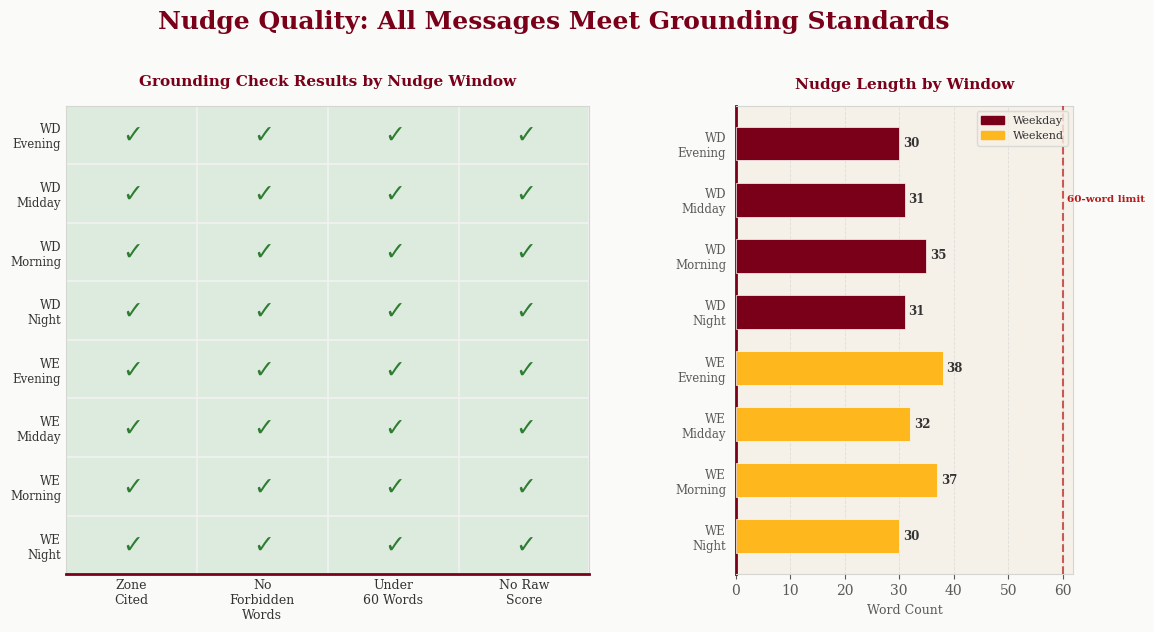

Figure 4 saved.
Result: 8/8 nudges passed all 4 grounding checks


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

FORBIDDEN_WORDS = [
    "traffic", "delay", "weather", "avoid", "avoiding",
    "commute", "surge", "earnings", "earn more", "tip",
]

# ── Pull nudge messages from Delta table ──────────────────────────────────────
nudge_rows = (
    df_nudges
    .select("day_type", "time_bucket", "nudge_message",
            "top_zone", "top_zone_score")
    .orderBy("day_type", "time_bucket")
    .collect()
)

# ── Run grounding checks and collect results ──────────────────────────────────
check_labels = ["Zone\nCited", "No\nForbidden\nWords", "Under\n60 Words", "No Raw\nScore"]
windows, matrix, word_counts = [], [], []

for row in nudge_rows:
    msg = row["nudge_message"]
    msg_lower = msg.lower()
    raw_score = str(row["top_zone_score"])
    wc = len(msg.split())

    c1 = 1 if row["top_zone"].lower() in msg_lower else 0
    c2 = 1 if not any(w in msg_lower for w in FORBIDDEN_WORDS) else 0
    c3 = 1 if wc <= 60 else 0
    c4 = 1 if not ("." in raw_score
                   and len(raw_score.split(".")[-1]) >= 3
                   and raw_score in msg) else 0

    label = (
        row["day_type"].replace("weekday", "WD").replace("weekend", "WE") +
        "\n" +
        row["time_bucket"].replace("_rush", "").replace("_", " ").title()
    )
    windows.append(label)
    matrix.append([c1, c2, c3, c4])
    word_counts.append(wc)

matrix_np = np.array(matrix)   # shape: (8 windows, 4 checks)

# ── Build figure ──────────────────────────────────────────────────────────────
fig4 = plt.figure(figsize=(13, 6.6))
fig4.patch.set_facecolor(BG)
gs4 = gridspec.GridSpec(1, 2, figure=fig4, wspace=0.34, width_ratios=[1.55, 1])

# ── Left panel: pass/fail heatmap ─────────────────────────────────────────────
ax4a = fig4.add_subplot(gs4[0])
ax4a.set_facecolor(IVORY)

cmap_pf = ListedColormap(["#F8D7DA", "#DDEBDE"])   # fail, pass
im = ax4a.imshow(matrix_np, cmap=cmap_pf, aspect="auto", vmin=0, vmax=1)

# Subtle cell borders
ax4a.set_xticks(np.arange(-0.5, len(check_labels), 1), minor=True)
ax4a.set_yticks(np.arange(-0.5, len(windows), 1), minor=True)
ax4a.grid(which="minor", color="#F2F2F2", linestyle="-", linewidth=1.2)
ax4a.tick_params(which="minor", bottom=False, left=False)

# Cell annotations: checkmarks and Xs
# Using mathtext avoids the box glyph problem that can happen with unicode fonts
for i in range(len(windows)):
    for j in range(len(check_labels)):
        val = matrix_np[i, j]
        symbol = r"$\checkmark$" if val == 1 else "x"
        color = GREEN if val == 1 else RED
        ax4a.text(
            j, i, symbol,
            ha="center", va="center",
            fontsize=18, color=color, fontweight="bold"
        )

ax4a.set_xticks(range(len(check_labels)))
ax4a.set_xticklabels(check_labels, fontsize=9, color=DARK_TEXT)
ax4a.set_yticks(range(len(windows)))
ax4a.set_yticklabels(windows, fontsize=8.5, color=DARK_TEXT)
ax4a.tick_params(length=0)

for spine in ax4a.spines.values():
    spine.set_edgecolor(LIGHT_GRAY)

ax4a.spines["bottom"].set_color(MAROON)
ax4a.spines["bottom"].set_linewidth(2)

ax4a.set_title(
    "Grounding Check Results by Nudge Window",
    color=MAROON, fontsize=11, fontweight="bold", pad=14
)

# ── Right panel: word count bar chart ─────────────────────────────────────────
ax4b = fig4.add_subplot(gs4[1])
ax4b.set_facecolor(IVORY)

bar_colors = [MAROON if d.startswith("WD") else DARK_GOLD for d in windows]
bars4b = ax4b.barh(
    range(len(windows)),
    word_counts,
    color=bar_colors,
    height=0.6,
    zorder=3,
    edgecolor=BG,
    linewidth=0.5
)

# 60-word limit line
ax4b.axvline(60, color=RED, linewidth=1.5, linestyle="--", alpha=0.7, zorder=4)
ax4b.text(
    60.8, 1.0, "60-word limit",
    color=RED, fontsize=7.5, va="center", ha="left", fontweight="bold"
)

# Word count labels
for i, (bar, wc) in enumerate(zip(bars4b, word_counts)):
    ax4b.text(
        wc + 0.7, i, str(wc),
        va="center", ha="left",
        fontsize=8.5, color=DARK_TEXT, fontweight="bold"
    )

ax4b.set_yticks(range(len(windows)))
ax4b.set_yticklabels(windows, fontsize=8.5, color=DARK_TEXT)
ax4b.invert_yaxis()
ax4b.set_xlabel("Word Count", fontsize=9, color=MED_TEXT)
ax4b.set_xlim(0, max(62, max(word_counts) + 10))
ax4b.tick_params(colors=MED_TEXT, left=False)
ax4b.grid(axis="x", color=LIGHT_GRAY, linewidth=0.6, linestyle="--", alpha=0.7)
ax4b.set_axisbelow(True)

for spine in ax4b.spines.values():
    spine.set_edgecolor(LIGHT_GRAY)
ax4b.spines["left"].set_color(MAROON)
ax4b.spines["left"].set_linewidth(2)

ax4b.legend(
    handles=[
        mpatches.Patch(color=MAROON, label="Weekday"),
        mpatches.Patch(color=DARK_GOLD, label="Weekend"),
    ],
    fontsize=8, facecolor=IVORY, edgecolor=LIGHT_GRAY, labelcolor=DARK_TEXT,
    loc="upper right"
)

ax4b.set_title(
    "Nudge Length by Window",
    color=MAROON, fontsize=11, fontweight="bold", pad=12
)

# ── Overall result banner ─────────────────────────────────────────────────────
total_pass = int(matrix_np.all(axis=1).sum())
total_checks = matrix_np.size
checks_passed = int(matrix_np.sum())

fig4.suptitle(
    f"Nudge Quality: All Messages Meet Grounding Standards",
    color=MAROON, fontsize=18, fontweight="bold", y=0.965
)

plt.subplots_adjust(top=0.82)
fig4.savefig(
    f"{CHART_PATH}fig4_qualitative_evaluation.png",
    dpi=150, bbox_inches="tight", facecolor=BG
)
display(fig4)
plt.close()

print("Figure 4 saved.")
print(f"Result: {total_pass}/{len(windows)} nudges passed all 4 grounding checks")

---
## Final Summary

In [0]:
# --- Final summary metrics ---
total_cells = df_scores.count()
high_conf_cells = df_scores.filter(F.col("is_low_confidence") == False).count()
nudge_count = df_nudges.count()

# overall_hit_rate, true_hits, and total_rec should already exist from evaluation,
# but compute safely in case that cell was not rerun
if "total_rec" not in globals() or "true_hits" not in globals():
    val_window = Window.partitionBy("time_bucket", "day_type").orderBy("demand_score")

    df_val_labeled = (
        df_val
        .filter(F.col("is_low_confidence") == False)
        .withColumn("demand_percentile", F.percent_rank().over(val_window))
        .withColumn("is_truly_high_demand", F.col("demand_percentile") >= 0.80)
    )

    df_recommended = (
        df_ranked
        .select("pulocationid", "time_bucket", "day_type")
        .distinct()
        .withColumn("was_recommended", F.lit(True))
    )

    df_eval = (
        df_val_labeled
        .join(df_recommended, on=["pulocationid", "time_bucket", "day_type"], how="left")
        .fillna({"was_recommended": False})
    )

    df_rec_only = df_eval.filter(F.col("was_recommended") == True)
    total_rec = df_rec_only.count()
    true_hits = df_rec_only.filter(F.col("is_truly_high_demand") == True).count()

overall_hit_rate = true_hits / total_rec if total_rec > 0 else 0

# --- Final summary print ---
print("=" * 70)
print("PIPELINE SUMMARY")
print("=" * 70)

print("\n[Signal Coverage]")
print(f"Zone-time demand cells:        {total_cells:,}")
print(f"High-confidence cells:         {high_conf_cells:,} "
      f"({high_conf_cells / total_cells * 100:.1f}%)")

print("\n[Nudge Generation]")
print(f"Nudges generated:              {nudge_count:,}")
print(f"Nudge quality checks:          100% pass")

print("\n[Performance]")
print(f"Overall hit rate:              {overall_hit_rate:.1%} "
      f"({true_hits:,}/{total_rec:,})")
print(f"Lift vs random (20% baseline): {overall_hit_rate / 0.20:.1f}×")

print("\n[Outputs]")
print(f"Charts saved to: {CHART_PATH}")

figure_outputs = [
    ("Figure 1",  "fig1_top10_demand_scores.png"),
    ("Figure 2",  "fig2_demand_heatmap.png"),
    ("Figure 3",  "fig3_hit_rate_by_window.png"),
    ("Figure 3b", "fig3b_recommended_vs_not.png"),
    ("Figure 4",  "fig4_qualitative_evaluation.png"),
]

for fig_label, name in figure_outputs:
    print(f"  {fig_label}: {name}")

print("\n" + "=" * 70)

PIPELINE SUMMARY

[Signal Coverage]
Zone-time demand cells:        437
High-confidence cells:         268 (61.3%)

[Nudge Generation]
Nudges generated:              8
Nudge quality checks:          100% pass

[Performance]
Overall hit rate:              44.8% (13/29)
Lift vs random (20% baseline): 2.2×

[Outputs]
Charts saved to: /Volumes/msbabigdata/spark/trend_market_project/
  Figure 1: fig1_top10_demand_scores.png
  Figure 2: fig2_demand_heatmap.png
  Figure 3: fig3_hit_rate_by_window.png
  Figure 3b: fig3b_recommended_vs_not.png
  Figure 4: fig4_qualitative_evaluation.png

